# Measurement of W + charm production using CMS Open Data:

This notebook involves the study of **W+charm** using CMS Open Data with W+Jets in final state. 

## Key Idea: 

This study is of the associated production of a W boson and a charm(c) quark at the LHC. This provides direct access to strange quark content of the proton at the W-boson mass energy scale. This sensitivity is due to dominance of $\bar{q}g \rightarrow W^{+} + \bar{c}$ and $qg \rightarrow W^{-} + c$ contibutions at leading order.

## Sample Used:

- **Simulated Dataset:** [Simulated dataset WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8 in NANOAODSIM format for 2016 collision data](https://opendata.cern.ch/record/69747). 80958227 events. 68 files. 73.9 GiB in total. (Here we take only partially available file - 2006990 events).

- **Collision Dataset:** TBA

## 1. Setup:

We use `coffea` for event processing, `awkward-array` and `dask` for jagged array handling, and `mplhep` to produce publication-ready CMS plots. All of them are available in the **Scikit-HEP** toolkit.

We also import `hist_functions` which contains helper plotter functions `make_hist`, `make_diff_hist`, `make_overlay_hist` and `os_ss_hist`.

In [1]:
import hist as h
import dask_awkward as dak
import numpy as np
import hist.dask as dhist
import hist_functions
from hist_functions import make_hist, make_diff_hist, make_overlay_hist, os_ss_hist
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
vector.register_awkward()

NanoAODSchema.warn_missing_crossrefs = False

## 2. Loading the data:
We load the WJetsToLNu sample of simulated $W\rightarrow \ell + \nu$. `dask` is used to lazily read the file to save resources and only read from disk whenever necessary.

In [2]:
# fname = "../../datasets/WJets_ToLNu_NANOAODSIM.root"
fname = "../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root"
print(f"Loading file: {fname}")
events = NanoEventsFactory.from_root(
    {fname: "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

Loading file: ../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root


dask.awkward<from-uproot, npartitions=1>

## 3. Event Selection Strategy:

### Analysis Strategy:

The Event selection strategy is as follows:
- **W-Boson selection:** Indetification of W-boson is done via its leptonic decay channel ($W \rightarrow \mu + \nu$) where we select high-$p_{T}$, isolated "tight" muons and missing transverse energy ($p_{T}^{miss}$).
- **Charm selection:** Identification of charm is done by looking for non-isolated "soft" muons from semi-leptonic decays of C-Hadron ($c \rightarrow s\mu\nu$).
- **OS-SS Subtraction:** The muon associated with the W-boson and the muon associated with the c-jet should have **opposite sign (OS)**. Here background processes like gluon splitting processes, Drell-Yan or $t\bar{t}$ are charge symmetric. By subtracting **same sign (SS)** events from OS events, we statistically reduce the background to obtain the signal.  

### Some Important Notes:

- In the $W+charm$ process at leading-order (LO), the electric charges of the $W$ boson and the $charm$ quark have opposite sign(OS).

- **Background:** Gluon splitting $q\bar{q} \rightarrow W + g \rightarrow W + c\bar{c}$ process produces both $c$ and $\bar{c}$; so the OS and SS events are both equally likely.  

- Detectors often reconstruct/tag only one c-jet candidate out of the two in the gluon splitting process.

- With only one picked c-jet, gluon splitting events becomes OS/SS-symmetric. That OS and SS yields from this background is equally likely.

- Why only one c-jet is tagged? The reason is limited acceptance, reconstruction efficiency and c-tagging efficiency meaning often times the detector can only reconstruct one of the either c-jet candidate from $g \rightarrow c\bar{c}$. The untagged c-jet candidate might be too soft or too forward to pass trigger or fail tagging.

- In $W + g \rightarrow g \rightarrow c \bar{c}$ background, if we keep a fixed $W$ charge. Let $S$ be true signal, $B$ a symmetric background: $N_{OS} = S + \dfrac{1}{2}B$ and $N_{SS} = 0 + \dfrac{1}{2}B$. Then subtract $N_{OS} - N_{SS}$, this cancels background and only signal remains. Here $N_{OS}$ and $N_{SS}$ are yields of opposite-sign and same-sign events.

## 4. Pre-selection and Initial Sanity Checks:

Here, we will select make object collections of _Muons_, _MET_ and _Jets_ that we will use later on in our analysis and also make some initial sanity checks and plots.

In [3]:
print("Defining Physics Objects...")

cutflow = {}

# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet

print("Defining physics objects ... Successful!")
print("--------------------------------------------")
# Count the number of events in the dataset:
n_events = dak.num(events, axis=0)
print("Total number of events in the dataset:", n_events.compute())

# --- CUTFLOW 1 --- #
cutflow["1. Total Events"] = n_events

# Count the number of muons in the dataset:
nMuons = dak.num(Muon, axis=1)
total_Muons = dak.sum(nMuons)
print("Total number of muons in the dataset:", total_Muons.compute())

# Count the number of jets in the dataset:
nJets = dak.num(Jet, axis=1)
total_Jets = dak.sum(nJets)
print("Total number of jets in the dataset:", total_Jets.compute())

Defining Physics Objects...
Defining physics objects ... Successful!
--------------------------------------------
Total number of events in the dataset: 250000
Total number of muons in the dataset: 94049
Total number of jets in the dataset: 940357


## 5. W-Boson Selection:

The following cuts are applied to obtain a high-$p_{T}$ and isolated "tight muon" with the trigger `HLT_IsoMu24`:

- Muon $p_{T}$ > 25 GeV. (high-$p_{T}$)
- Muon $\eta$ < 2.4. 
- Muon `pfRelIso04_all` < 0.15. (isolated)
- Muon `tightID` == True.

We additionally also put a cut on the Transverse Mass ($M_{T}$ > 50 GeV) of Muon+MET system to ensure the selected candidate is associated with a W-Boson.

In [4]:
print("Defining W Selection ...")
######################################
## W-Boson -> Mu Nu Channel Selection:
######################################

# W-Boson selection cuts:
W_MuMask = (
    (Muon.pt > 25) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == 1) &
    (Muon.pfRelIso04_all < 0.15)
    )

# Transverse mass calculation and cut:
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]

# Select events with exactly ONE W muon:
nMu = dak.num(W_Muons, axis=1)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

nMu = dak.num(W_Muons, axis=1)
nMu = dak.sum(nMu)
# --- CUTFLOW 2 --- #
cutflow["2. W-Muons after cuts"] = nMu
print("Total number of W muons:", nMu.compute())

Defining W Selection ...
Total number of W muons: 31118


## 6. Charm Selection:

The following cuts are applied to obtain a non-isolated "soft" muon:

- Muon $p_{T}$ < 25 GeV.
- Muon $\eta$ < 2.4. 
- Muon `pfRelIso04_all` > 0.2. (non-isolated)
- Muon `tightID` == True.
- Muon `sip3d` > 2.

Then we match these soft muons with the nearest jets and categorise them as c-jets (jets originating from c-Hadrons). The jets should also have: $p_{T}$ > 30 GeV and $\eta$ < 2.

In [5]:
print("Defining charm Selection ...")
###############################################
## C-jet -> Mu X Channel Selection (soft muon):
###############################################

cMuPassCuts = (
    (Muon.pt < 25) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) &
    (Muon.jetIdx >= 0) 
    # (Muon.tightId == 1)
)
# Impact parameter significance cut (3D):
sip2d = (abs(Muon.dxy) / Muon.dxyErr) 
sip3d = Muon.sip3d
ip2dSigMask = (sip2d > 2)
ip3dSigMask = ((sip3d) > 2)

soft_muon = Muon[cMuPassCuts & ip3dSigMask]

# Print the number of soft muons passing the selection:
nSoftMuons = dak.num(soft_muon, axis=1)
total_SoftMuons = dak.sum(nSoftMuons)
print("Total number of soft muons:", total_SoftMuons.compute())

###############################################
## Jet matching via jetIdx (soft muon <-> jets)
## - uses Muon.jetIdx to pick the matched jet
## - applies jet kinematic cuts on matched jets
###############################################

# Matched jets for each soft muon (evt, nMu)
matched_jets = Jet[soft_muon.jetIdx]

# Apply jet kinematic cuts to matched jets
matched_jet_mask = (
    (matched_jets.pt > 30) &
    (abs(matched_jets.eta) < 2.4)
)

# Keep only soft muons and matched jets passing jet cuts
soft_muon_in_goodjet = soft_muon[matched_jet_mask]
c_Jets = matched_jets[matched_jet_mask]

# Summary of matched jets passing cuts
nMatchedJets = dak.num(c_Jets, axis=1)
total_MatchedJets = dak.sum(nMatchedJets)
print("Total number of matched jets passing cuts:", total_MatchedJets.compute())

# Select events with atleast one c-jet:
nC_Jets = dak.num(c_Jets, axis=1)
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

# Total number of cJets in the dataset:
nC_Jets = dak.num(c_Jets, axis=1)
total_cJets = dak.sum(nC_Jets)

# --- CUTFLOW 3 --- #
cutflow["3. c-Jets after cuts"] = total_cJets
print("Total number of c-jets in the dataset:", total_cJets.compute())

Defining charm Selection ...
Total number of soft muons: 4146
Total number of matched jets passing cuts: 1460
Total number of c-jets in the dataset: 1460


## 7. Signal Extraction:

We want exactly one W boson candidate and at least one c-jet candidate. We then separate them into **Opposite Sign (OS)** (Signal + Background) and **Same Sign (SS)** (Background Only).

In [ ]:
print("Defining Signal Region...")

# W+c Event Mask: events with exactly one W muon and at least one c-jet:
Wc_evt_mask = evt_has_1WMu & evt_has_cJet
nWC_Events = dak.sum(Wc_evt_mask)
print("The number of events containing W+c candidates:", nWC_Events.compute())

# --- CUTFLOW 4 --- #
cutflow["4. W+c Events"] = nWC_Events

# Apply the event mask to ALL collections BEFORE building OS/SS masks
Final_W = W_Muons[Wc_evt_mask]

# For c-jets and soft muons, we need to filter soft_muon_in_goodjet first,
# THEN apply evt_has_cJet, THEN apply Wc_evt_mask
soft_muon_final = soft_muon_in_goodjet[evt_has_cJet][Wc_evt_mask]
c_jets_final = c_Jets[Wc_evt_mask]

# OS - SS categorization using broadcast:
w_charge = Final_W.charge[:, 0]
soft_charge = soft_muon_final.charge

# Broadcast W charge to match number of soft muons
w_charge_broadcast = dak.broadcast_arrays(w_charge, soft_charge)[0]

is_OS = w_charge_broadcast != soft_charge
is_SS = w_charge_broadcast == soft_charge

# Now OS/SS masks are aligned with both c_jets_final and soft_muon_final
cjet_pt_OS = dak.flatten(c_jets_final[is_OS].pt)
cjet_pt_SS = dak.flatten(c_jets_final[is_SS].pt)

# Count OS/SS lepton pairs
nOS_pairs = int(dak.sum(is_OS).compute())
nSS_pairs = int(dak.sum(is_SS).compute())
print(f"OS lepton pairs: {nOS_pairs}")
print(f"SS lepton pairs: {nSS_pairs}")

Defining Signal Region...
The number of events containing W+c candidates: 151


## 8. Plots and Compute:

Let's plot all the control plots and also compute them as we plot them (intrinsically built into the `hist_functions`). The plots are to see if we need to put any additional cuts or tune our cuts to increase yields. 

Generating histograms...


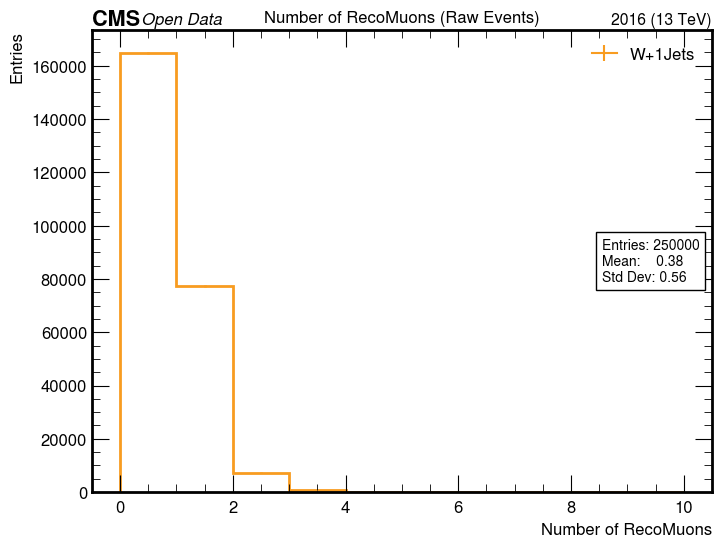

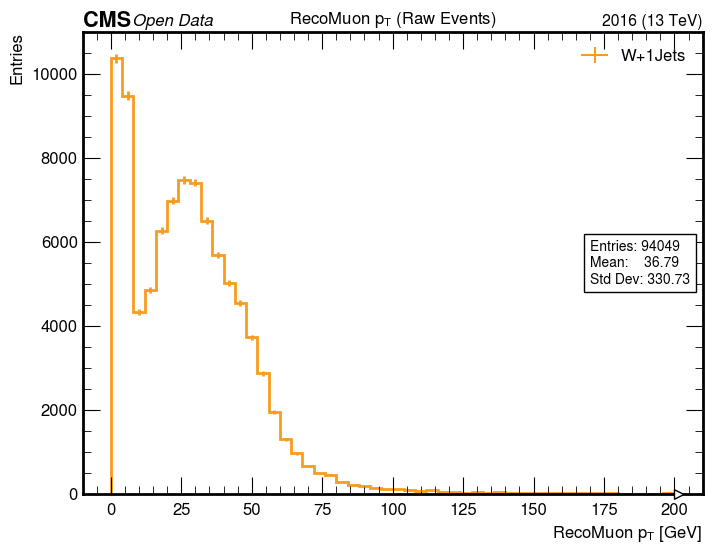

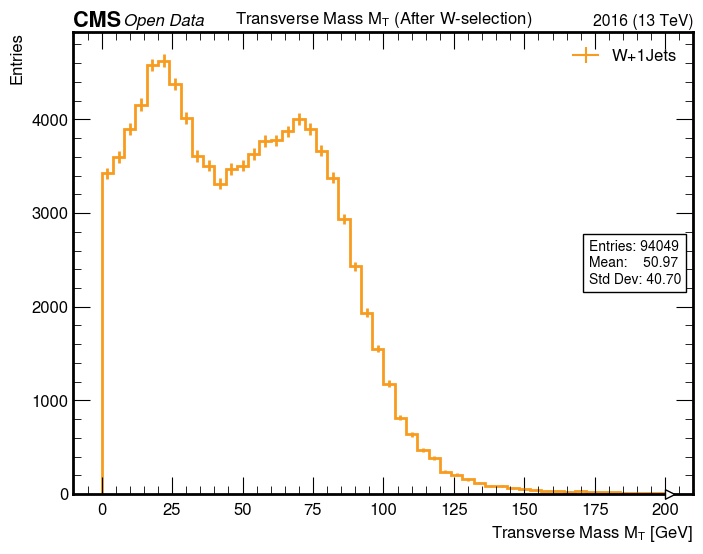

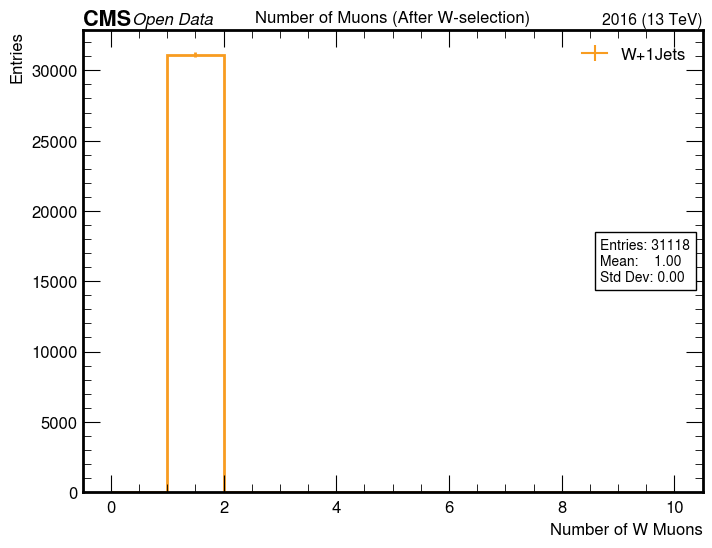

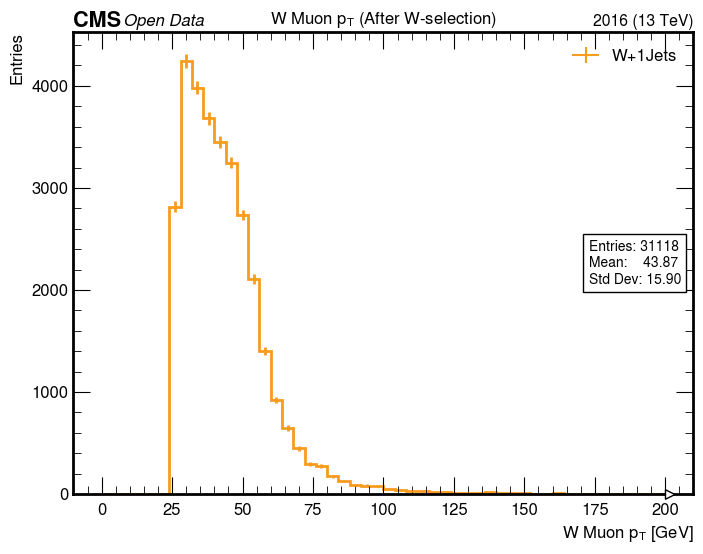

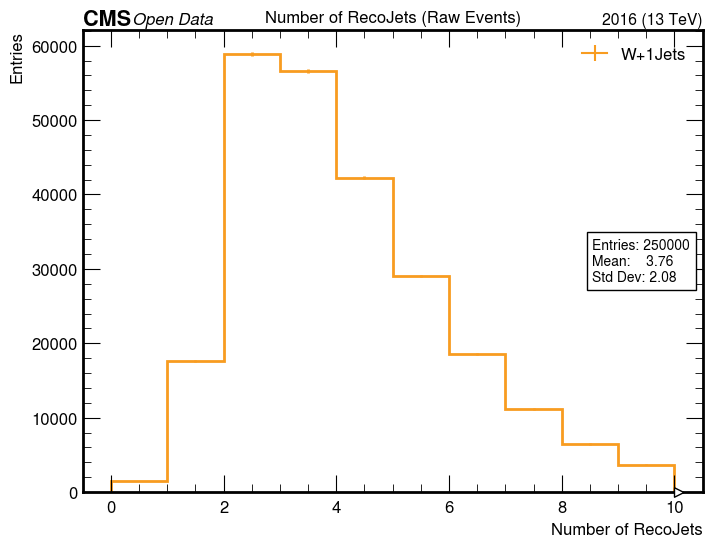

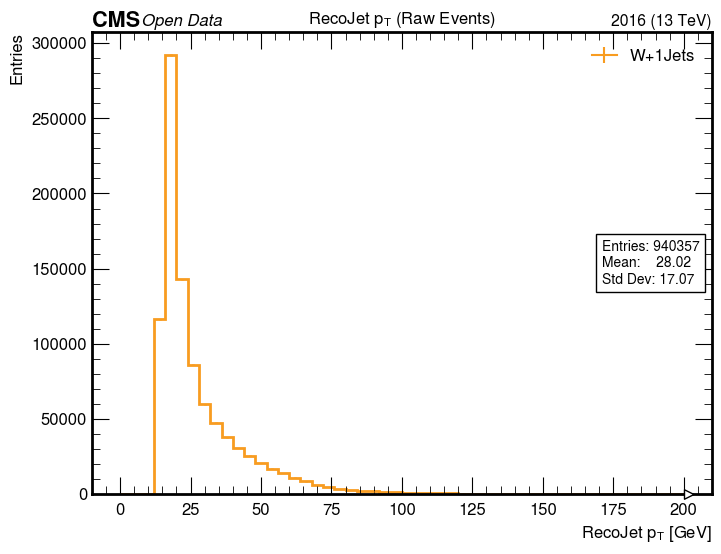

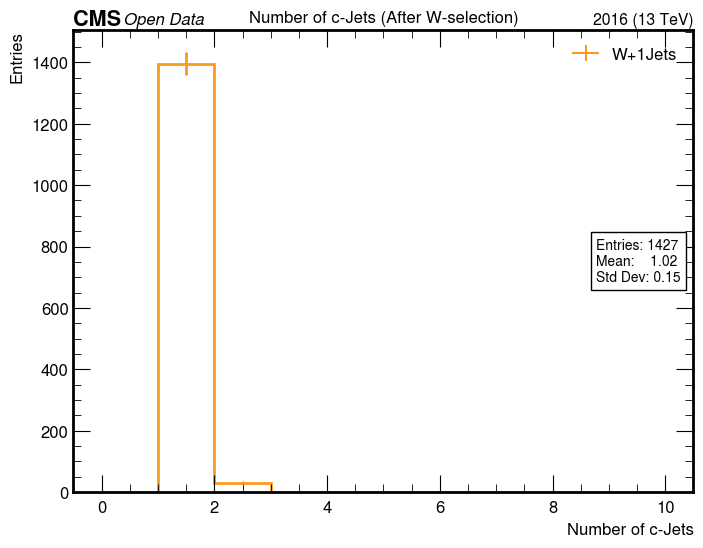

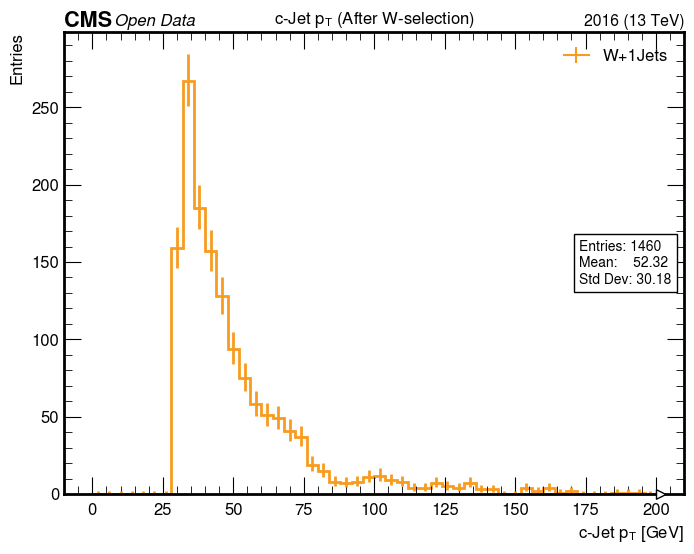

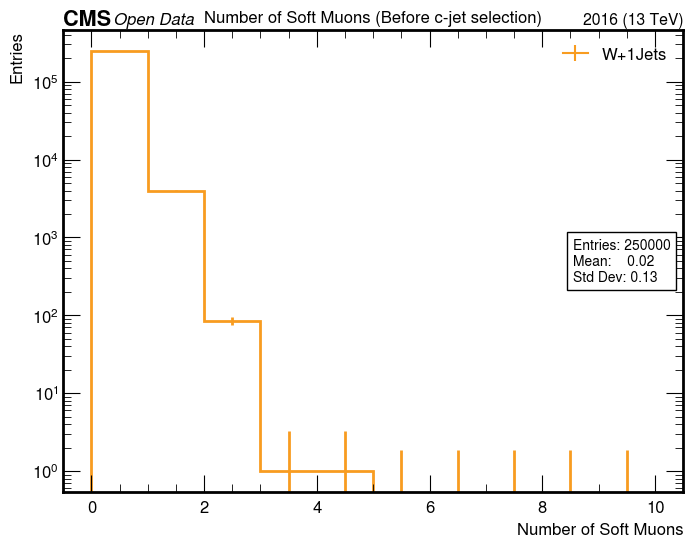

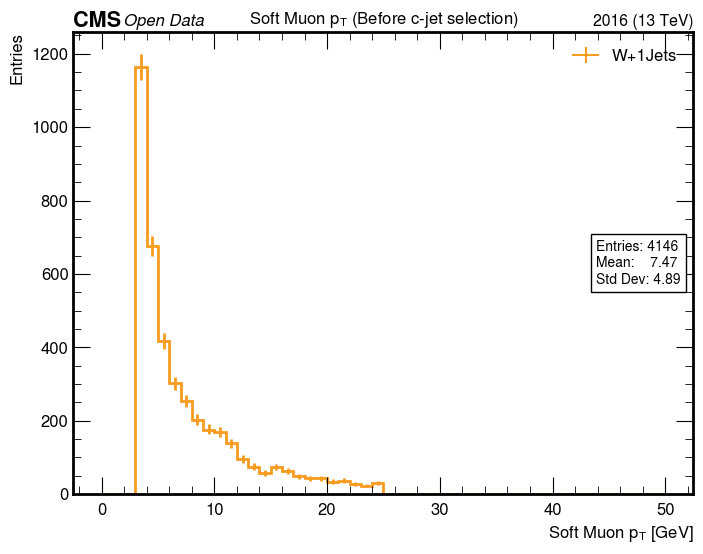

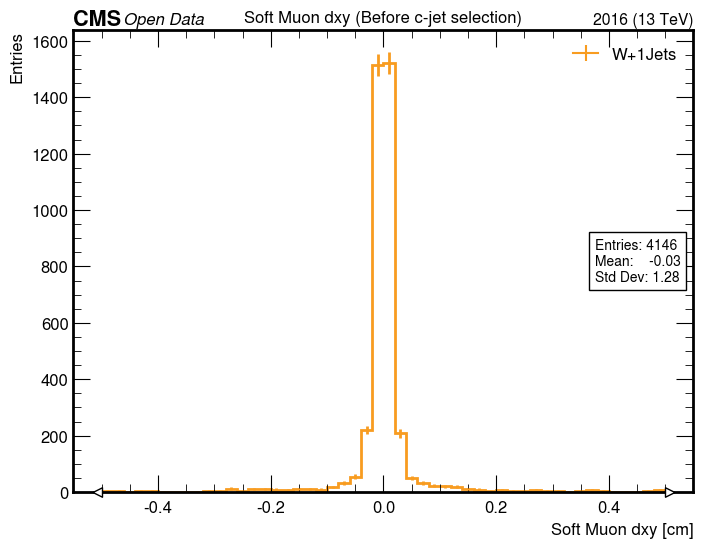

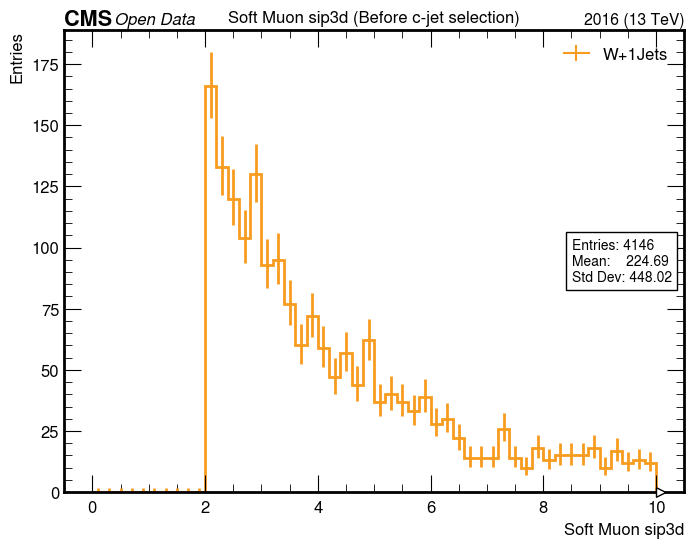

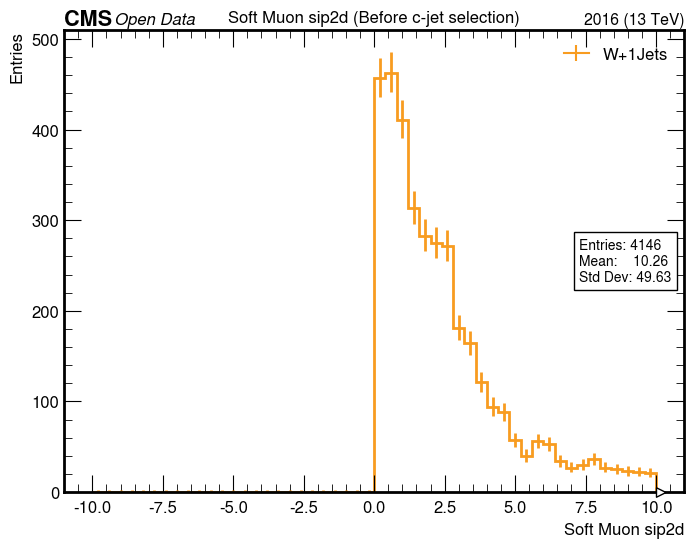

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Soft Muon sip2d (Before c-jet selection)'}, xlabel='Soft Muon sip2d', ylabel='Entries'>)

In [8]:
print("Generating histograms...")

# Number of RecoMuons histogram:
nRecoMuons = dak.num(Muon, axis=1)
make_hist(
    data=nRecoMuons,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of RecoMuons",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of RecoMuons (Raw Events)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# RecoMuon pT histogram:
RecoMuon_pt = dak.flatten(Muon.pt)
make_hist(
    data=RecoMuon_pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="RecoMuon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="RecoMuon $p_{T}$ (Raw Events)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Transverse Mass histogram:
transverse_mass = dak.flatten(Mt)
make_hist(
    data=transverse_mass,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="Transverse Mass $M_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="Transverse Mass $M_{T}$ (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of W muons histogram:
nWMuons = dak.num(W_Muons, axis=1)
make_hist(
    data=nWMuons,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of W Muons",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of Muons (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# W muon pT histogram:
W_Muon_pt = dak.flatten(W_Muons.pt)
make_hist(
    data=W_Muon_pt,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="W Muon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="W Muon $p_{T}$ (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of Reco Jets histogram:
nRecoJets = dak.num(Jet, axis=1)
make_hist( 
    data=nRecoJets, 
    nBins=10,
    lo=0, 
    hi=10, 
    xlabel="Number of RecoJets", 
    ylabel="Entries", 
    label="W+1Jets",
    title="Number of RecoJets (Raw Events)", 
    fname=None, 
    logy=False, 
    ax=None, 
    show=True, 
    return_hist=False, 
    show_stats=True, 
    histtype="step"
)

# Jets pT histogram:
RecoJet_pT = dak.flatten(Jet.pt)
make_hist(
    data=RecoJet_pT,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="RecoJet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="RecoJet $p_{T}$ (Raw Events)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of c-Jets:
nCJets = dak.num(c_Jets, axis=1)
make_hist(
    data=nCJets,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of c-Jets",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of c-Jets (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# c-Jet pT histogram:
cJet_pT = dak.flatten(c_Jets.pt)
make_hist(
    data=cJet_pT,
    nBins=50,
    lo=0,
    hi=200,
    xlabel="c-Jet $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="c-Jet $p_{T}$ (After W-selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Number of soft muons histogram:
nSoftMuons = dak.num(soft_muon, axis=1)
make_hist(
    data=nSoftMuons,
    nBins=10,
    lo=0,
    hi=10,
    xlabel="Number of Soft Muons",
    ylabel="Entries",
    label="W+1Jets",
    title="Number of Soft Muons (Before c-jet selection)",
    fname=None,
    logy=True,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon pT histogram:
softMuon_pT = dak.flatten(soft_muon.pt)
make_hist(
    data=softMuon_pT,
    nBins=50,
    lo=0,
    hi=50,
    xlabel="Soft Muon $p_{T}$ [GeV]",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon $p_{T}$ (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon dxy histogram:
softMuon_dxy = dak.flatten(soft_muon.dxy)
make_hist(
    data=softMuon_dxy,
    nBins=50,
    lo=-0.5,
    hi=0.5,
    xlabel="Soft Muon dxy [cm]",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon dxy (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon sip3d histogram:
soft_muon_sip3d = dak.flatten(soft_muon.sip3d)
make_hist(
    data=soft_muon_sip3d,
    nBins=50,
    lo=0,
    hi=10,
    xlabel="Soft Muon sip3d",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon sip3d (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

# Soft Muon sip2d histogram:
soft_muon_sip2d = dak.flatten(abs((soft_muon.dxy)/ soft_muon.dxyErr))
make_hist(
    data=soft_muon_sip2d,
    nBins=50,
    lo=-10,
    hi=10,
    xlabel="Soft Muon sip2d",
    ylabel="Entries",
    label="W+1Jets",
    title="Soft Muon sip2d (Before c-jet selection)",
    fname=None,
    logy=False,
    ax=None,
    show=True,
    return_hist=False,
    show_stats=True,
    histtype="step",
)

## 9. OS - SS Subtraction:

We subtract the **Same-Sign(SS)** background from **Opposite-Sign(OS)** $W+c$ events. 

1. **Opposite Sign (OS):** The events containing muon associated with the W-Boson and the soft muon associated with the charm should have opposite charges ($Q_{\mu, W} \neq Q_{\mu, soft}$).
2. **Same Sign (SS):** The events containing muons having same charge are treated as background and need to be reduced.
3. **OS-SS Subtraction:** We statistically subtract SS distribution from OS distribution, cancelling out the background.